In [13]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter

In [14]:
# Set style for your report's visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [15]:
# Upload the dataset files
TRAIN_PATH = '../data/Restaurants_Train_v2.xml'
TEST_PATH = '../data/Restaurants_Test_Data_phaseB.xml'

In [16]:
# Function to parse XML and convert to DataFrame
def parse_absa_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    
    rows = []
    for sentence in root.findall('sentence'):
        text = sentence.find('text').text
        aspect_terms = sentence.find('aspectTerms')
        
        if aspect_terms is not None:
            for at in aspect_terms.findall('aspectTerm'):
                rows.append({
                    'text': text,
                    'aspect': at.get('term'),
                    'sentiment': at.get('polarity'),
                    'from': at.get('from'),
                    'to': at.get('to')
                })
    
    return pd.DataFrame(rows)

# Create the DataFrames
df_train = parse_absa_xml(TRAIN_PATH)
df_test = parse_absa_xml(TEST_PATH)

print(f"Train Shape: {df_train.shape}")
print(f"Test Shape: {df_test.shape}")
df_train.head()

Train Shape: (3693, 5)
Test Shape: (1134, 5)


,text,aspect,sentiment,from,to
0,But the staff was so horrible to us.,staff,negative,8,13
1,"To be completely fair, the only redeeming fact...",food,positive,57,61
2,"The food is uniformly exceptional, with a very...",food,positive,4,8
3,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62
4,"The food is uniformly exceptional, with a very...",menu,neutral,141,145


In [17]:
#Data cleaning and preprocessing
# Check unique sentiments
print("Sentiments before cleaning:", df_train['sentiment'].unique())

# 1. Remove 'conflict' labels
df_train = df_train[df_train['sentiment'] != 'conflict'].reset_index(drop=True)
df_test = df_test[df_test['sentiment'] != 'conflict'].reset_index(drop=True)

# 2. Basic text normalization (Lowercasing text and aspects)
df_train['text'] = df_train['text'].str.lower()
df_train['aspect'] = df_train['aspect'].str.lower()
df_test['text'] = df_test['text'].str.lower()
df_test['aspect'] = df_test['aspect'].str.lower()

print(f"Cleaned Train Shape: {df_train.shape}")

Sentiments before cleaning: <StringArray>
['negative', 'positive', 'neutral', 'conflict']
Length: 4, dtype: str
Cleaned Train Shape: (3602, 5)


In [18]:
summary_data = {
    'Metric': ['Total Samples', 'Positive', 'Negative', 'Neutral'],
    'Train Set': [
        len(df_train),
        len(df_train[df_train['sentiment'] == 'positive']),
        len(df_train[df_train['sentiment'] == 'negative']),
        len(df_train[df_train['sentiment'] == 'neutral'])
    ],
    'Test Set': [
        len(df_test),
        len(df_test[df_test['sentiment'] == 'positive']),
        len(df_test[df_test['sentiment'] == 'negative']),
        len(df_test[df_test['sentiment'] == 'neutral'])
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df

,Metric,Train Set,Test Set
0,Total Samples,3602,1134
1,Positive,2164,0
2,Negative,805,0
3,Neutral,633,0


In [ ]:
# Visualize sentiment distribution
import xml.etree.ElementTree as ET
tree = ET.parse(TEST_PATH)
root = tree.getroot()

# Print first sentence to see structure
for sentence in root.findall('sentence')[:2]:
    print(ET.tostring(sentence, encoding='unicode'))

<sentence id="32897564#894393#2">
        <text>The bread is top notch as well.</text>
        <aspectTerms>
            <aspectTerm term="bread" from="4" to="9" />
        </aspectTerms>
        <aspectCategories>
            <aspectCategory category="food" />
        </aspectCategories>
    </sentence>
    
<sentence id="33070600#670328#0">
        <text>I have to say they have one of the fastest delivery times in the city.</text>
        <aspectTerms>
            <aspectTerm term="delivery times" from="43" to="57" />
        </aspectTerms>
        <aspectCategories>
            <aspectCategory category="service" />
        </aspectCategories>
    </sentence>
    


In [26]:
from sklearn.model_selection import train_test_split

# Split train data yourself — 80% train, 20% test
train, test = train_test_split(
    df_train, 
    test_size=0.2, 
    random_state=42,
    stratify=df_train['sentiment']  # important for imbalanced data
)

print("Train size:", len(train))
print("Test size:", len(test))
print("\nTest sentiment distribution:")
print(test['sentiment'].value_counts())

Train size: 2881
Test size: 721

Test sentiment distribution:
sentiment
positive    433
negative    161
neutral     127
Name: count, dtype: int64


C:\Users\ananya\AppData\Local\Temp\ipykernel_53360\410086553.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_train, palette='viridis')


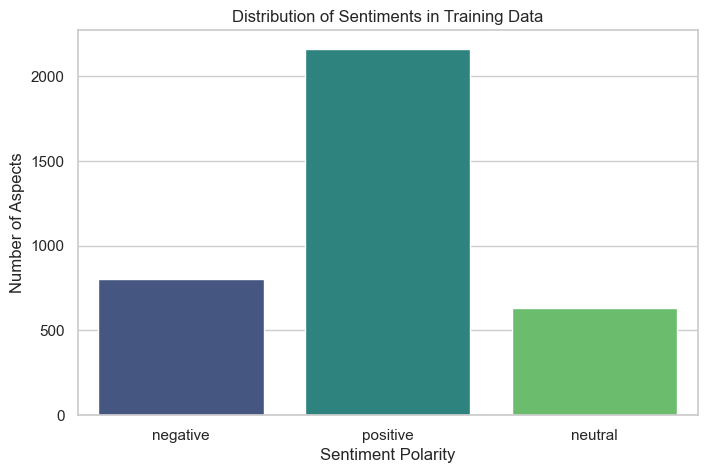

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df_train, palette='viridis')
plt.title('Distribution of Sentiments in Training Data')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Aspects')
plt.savefig('../results/sentiment_distribution.png') # Saves the image for your report
plt.show()

C:\Users\ananya\AppData\Local\Temp\ipykernel_53360\1553914997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aspects.values, y=top_aspects.index, palette='magma')


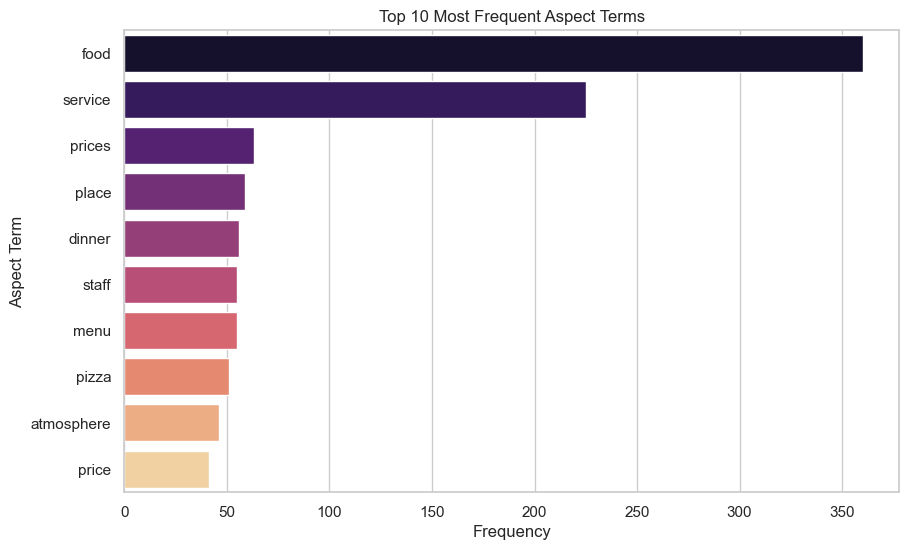

In [28]:
#top 10 most common aspects
top_aspects = df_train['aspect'].value_counts().head(10)

sns.barplot(x=top_aspects.values, y=top_aspects.index, palette='magma')
plt.title('Top 10 Most Frequent Aspect Terms')
plt.xlabel('Frequency')
plt.ylabel('Aspect Term')
plt.savefig('../results/top_aspects.png')
plt.show()

In [29]:
# Save cleaned data so Notebook 2 can use it
df_train.to_csv('../data/cleaned_train.csv', index=False)
df_test.to_csv('../data/cleaned_test.csv', index=False)
print("Data saved successfully!")

Data saved successfully!
